# Model Architecture Exploration

This notebook walks through the three segmentation models implemented for the **ACDC cardiac MRI dataset**.

| Model | Key idea |
|---|---|
| **U-Net** | Classic encoder-decoder with skip connections |
| **Attention U-Net** | U-Net + soft attention gates on every skip connection |
| **TransUNet** | CNN encoder → Transformer bottleneck → CNN decoder |

All models share the same interface:
- **Input**: `(B, 1, 256, 256)` — single-channel MRI slice
- **Output**: `(B, 4, 256, 256)` — raw logits for 4 classes (Background / RV / Myocardium / LV)

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import OrderedDict

from src.models import UNet, AttentionUNet, TransUNet

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


---
## 1. Instantiate Models

In [2]:
unet        = UNet(in_channels=1, num_classes=4).to(DEVICE)
attn_unet   = AttentionUNet(in_channels=1, num_classes=4).to(DEVICE)
transunet   = TransUNet(in_channels=1, num_classes=4, d_model=512, n_heads=8, n_layers=6).to(DEVICE)

models = OrderedDict([
    ("UNet",         unet),
    ("AttentionUNet", attn_unet),
    ("TransUNet",    transunet),
])

print("All models created successfully.")

All models created successfully.


---
## 2. Parameter Counts

In [3]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print(f"{'Model':<20} {'Total params':>15} {'Trainable':>15}")
print("-" * 52)
param_data = {}
for name, model in models.items():
    total, trainable = count_params(model)
    param_data[name] = total
    print(f"{name:<20} {total:>15,} {trainable:>15,}")

Model                   Total params       Trainable
----------------------------------------------------
UNet                      31,383,876      31,383,876
AttentionUNet             31,908,524      31,908,524
TransUNet                 24,307,012      24,307,012


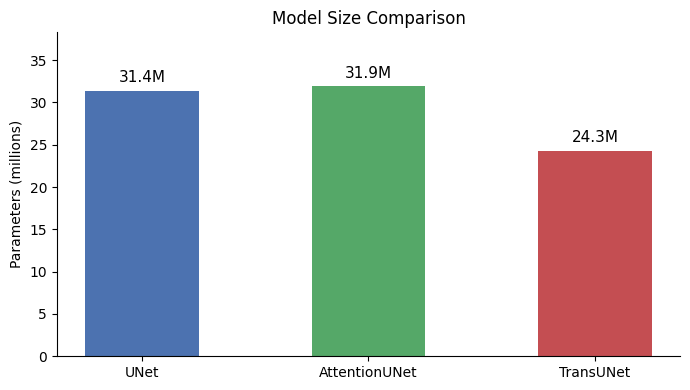

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(param_data.keys(), [v / 1e6 for v in param_data.values()], color=colors, width=0.5)
ax.bar_label(bars, fmt="%.1fM", padding=4, fontsize=11)
ax.set_ylabel("Parameters (millions)")
ax.set_title("Model Size Comparison")
ax.set_ylim(0, max(param_data.values()) / 1e6 * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## 3. Architecture Overview

### U-Net

```
Input (1×256×256)
   │
   ├─ Encoder block 1 ──────────────────────────────────── skip s1 (64ch @ 256×256)
   │     DoubleConv(1→64) + MaxPool
   ├─ Encoder block 2 ──────────────────────────────────── skip s2 (128ch @ 128×128)
   │     DoubleConv(64→128) + MaxPool
   ├─ Encoder block 3 ──────────────────────────────────── skip s3 (256ch @ 64×64)
   │     DoubleConv(128→256) + MaxPool
   ├─ Encoder block 4 ──────────────────────────────────── skip s4 (512ch @ 32×32)
   │     DoubleConv(256→512) + MaxPool
   │
   ├─ Bottleneck: DoubleConv(512→1024)  →  16×16
   │
   ├─ Decoder block 4: Upsample + concat(s4) → DoubleConv(1536→512)
   ├─ Decoder block 3: Upsample + concat(s3) → DoubleConv(768→256)
   ├─ Decoder block 2: Upsample + concat(s2) → DoubleConv(384→128)
   ├─ Decoder block 1: Upsample + concat(s1) → DoubleConv(192→64)
   │
   └─ Head: Conv1×1(64→4)
Output (4×256×256)
```

### Attention U-Net

Identical to U-Net except each skip connection is passed through an **Attention Gate** before concatenation:

```
AttentionGate(g=decoder_feature, x=encoder_skip)
   ├─ W_g: Conv1×1(F_g → F_int) + BN
   ├─ W_x: Conv1×1(F_l → F_int) + BN
   ├─ Upsample g to match x spatial size
   ├─ psi: ReLU → Conv1×1(F_int → 1) + BN + Sigmoid  → attention map α ∈ [0,1]
   └─ output = α × x   (highlights relevant spatial regions)
```

### TransUNet

The transformer receives the **pooled** output of enc4 (16×16), giving 256 tokens. The 32×32 enc4 skip is used by the decoder normally.

```
Input (1×256×256)
   │
   ├─ CNN enc1: DoubleConv(1→64)   + MaxPool  → skip s1 (64ch  @ 256×256), pooled → 128×128
   ├─ CNN enc2: DoubleConv(64→128) + MaxPool  → skip s2 (128ch @ 128×128), pooled → 64×64
   ├─ CNN enc3: DoubleConv(128→256)+ MaxPool  → skip s3 (256ch @ 64×64),   pooled → 32×32
   ├─ CNN enc4: DoubleConv(256→256)+ MaxPool  → skip s4 (256ch @ 32×32),   pooled → 16×16
   │
   ├─ Tokenise: (B, 256, 16, 16) flatten → (B, 256 tokens, 256)  [linear proj to d_model=512]
   ├─ Transformer encoder: 6 layers, 8 heads, d_model=512
   │     Each token attends to all 255 others → global context
   ├─ Project back: (B, 256, 512) → (B, 256, 256) → reshape → (B, 256, 16, 16)
   │
   ├─ CNN dec4: Upsample(16→32)   + concat(s4) → DoubleConv(512→256)
   ├─ CNN dec3: Upsample(32→64)   + concat(s3) → DoubleConv(512→128)
   ├─ CNN dec2: Upsample(64→128)  + concat(s2) → DoubleConv(256→64)
   ├─ CNN dec1: Upsample(128→256) + concat(s1) → DoubleConv(128→64)
   │
   └─ Head: Conv1×1(64→4)
Output (4×256×256)
```

---
## 4. Layer-by-Layer Summary

A custom summary function that prints each named module with its parameter count — no external libraries needed.

In [5]:
def model_summary(model, name):
    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")
    print(f"{'Layer':<40} {'Type':<20} {'Params':>8}")
    print("-" * 70)
    total = 0
    for mod_name, module in model.named_modules():
        # only leaf modules (no containers)
        if len(list(module.children())) == 0:
            params = sum(p.numel() for p in module.parameters())
            total += params
            layer_type = type(module).__name__
            display_name = mod_name if mod_name else "(root)"
            if params > 0:
                print(f"{display_name:<40} {layer_type:<20} {params:>8,}")
    print("-" * 70)
    print(f"{'Total trainable parameters':<60} {total:>8,}")

for name, model in models.items():
    model_summary(model, name)


  UNet
Layer                                    Type                   Params
----------------------------------------------------------------------
enc1.conv.net.0                          Conv2d                    576
enc1.conv.net.1                          BatchNorm2d               128
enc1.conv.net.3                          Conv2d                 36,864
enc1.conv.net.4                          BatchNorm2d               128
enc2.conv.net.0                          Conv2d                 73,728
enc2.conv.net.1                          BatchNorm2d               256
enc2.conv.net.3                          Conv2d                147,456
enc2.conv.net.4                          BatchNorm2d               256
enc3.conv.net.0                          Conv2d                294,912
enc3.conv.net.1                          BatchNorm2d               512
enc3.conv.net.3                          Conv2d                589,824
enc3.conv.net.4                          BatchNorm2d               51

---
## 5. Feature Map Shape Flow

Register forward hooks to record the output shape of key named submodules as a dummy input flows through each model.

In [6]:
def trace_shapes(model, input_shape=(1, 1, 256, 256), watch_names=None):
    """
    Run a dummy forward pass and return a dict of {module_name: output_shape}
    for every named module whose name is in watch_names.
    If watch_names is None, captures all direct children.
    """
    records = OrderedDict()
    hooks   = []

    if watch_names is None:
        watch_names = [n for n, _ in model.named_children()]

    def make_hook(name):
        def hook(module, inp, out):
            if isinstance(out, torch.Tensor):
                records[name] = tuple(out.shape)
            elif isinstance(out, (tuple, list)) and isinstance(out[0], torch.Tensor):
                # DownBlock returns (pooled, skip) — record both
                records[name + " [pooled]"] = tuple(out[0].shape)
                records[name + " [skip]"]   = tuple(out[1].shape)
        return hook

    for name, module in model.named_children():
        if name in watch_names:
            hooks.append(module.register_forward_hook(make_hook(name)))

    x = torch.zeros(input_shape).to(DEVICE)
    model.eval()
    with torch.no_grad():
        out = model(x)
    records["output"] = tuple(out.shape)

    for h in hooks:
        h.remove()

    return records


def print_shape_flow(model, name):
    records = trace_shapes(model)
    print(f"\n{'='*55}")
    print(f"  {name} — feature map shapes")
    print(f"{'='*55}")
    print(f"  input  →  (1, 1, 256, 256)")
    for stage, shape in records.items():
        B, *rest = shape
        print(f"  {stage:<22} →  ({B}, {', '.join(map(str, rest))})")

for name, model in models.items():
    print_shape_flow(model, name)


  UNet — feature map shapes
  input  →  (1, 1, 256, 256)
  enc1 [pooled]          →  (1, 64, 128, 128)
  enc1 [skip]            →  (1, 64, 256, 256)
  enc2 [pooled]          →  (1, 128, 64, 64)
  enc2 [skip]            →  (1, 128, 128, 128)
  enc3 [pooled]          →  (1, 256, 32, 32)
  enc3 [skip]            →  (1, 256, 64, 64)
  enc4 [pooled]          →  (1, 512, 16, 16)
  enc4 [skip]            →  (1, 512, 32, 32)
  bottleneck             →  (1, 1024, 16, 16)
  dec4                   →  (1, 512, 32, 32)
  dec3                   →  (1, 256, 64, 64)
  dec2                   →  (1, 128, 128, 128)
  dec1                   →  (1, 64, 256, 256)
  head                   →  (1, 4, 256, 256)
  output                 →  (1, 4, 256, 256)

  AttentionUNet — feature map shapes
  input  →  (1, 1, 256, 256)
  enc1 [pooled]          →  (1, 64, 128, 128)
  enc1 [skip]            →  (1, 64, 256, 256)
  enc2 [pooled]          →  (1, 128, 64, 64)
  enc2 [skip]            →  (1, 128, 128, 128)
  enc3 [

---
## 6. Spatial Resolution vs Channels Chart

Visualise how spatial resolution and channel depth trade off through the encoder of each model.

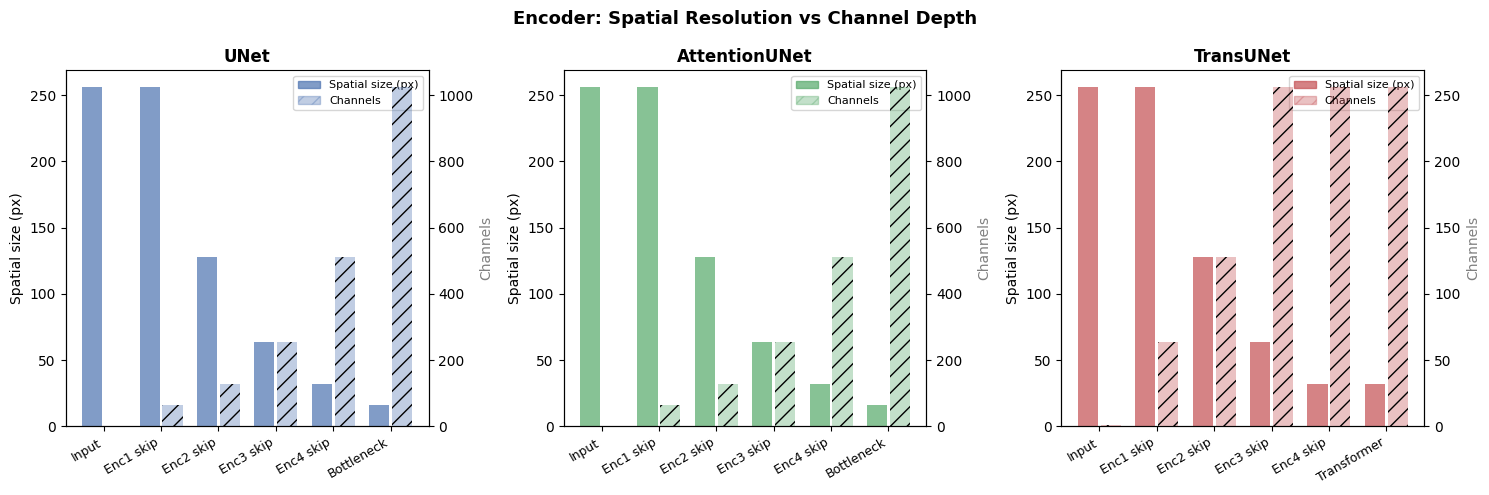

In [7]:
# Encoder stages: (spatial_size, channels) for each model
stages = {
    "UNet": [
        ("Input",       256, 1),
        ("Enc1 skip",   256, 64),
        ("Enc2 skip",   128, 128),
        ("Enc3 skip",   64,  256),
        ("Enc4 skip",   32,  512),
        ("Bottleneck",  16,  1024),
    ],
    "AttentionUNet": [
        ("Input",       256, 1),
        ("Enc1 skip",   256, 64),
        ("Enc2 skip",   128, 128),
        ("Enc3 skip",   64,  256),
        ("Enc4 skip",   32,  512),
        ("Bottleneck",  16,  1024),
    ],
    "TransUNet": [
        ("Input",        256, 1),
        ("Enc1 skip",    256, 64),
        ("Enc2 skip",    128, 128),
        ("Enc3 skip",    64,  256),
        ("Enc4 skip",    32,  256),
        ("Transformer",  32,  256),
    ],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colors_enc = ["#4C72B0", "#55A868", "#C44E52"]

for ax, (model_name, stage_list), color in zip(axes, stages.items(), colors_enc):
    labels   = [s[0] for s in stage_list]
    spatial  = [s[1] for s in stage_list]
    channels = [s[2] for s in stage_list]

    x = np.arange(len(labels))
    ax2 = ax.twinx()

    ax.bar(x - 0.2, spatial,  0.35, label="Spatial (px)",  color=color, alpha=0.7)
    ax2.bar(x + 0.2, channels, 0.35, label="Channels", color=color, alpha=0.35, hatch="//")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Spatial size (px)", color="black")
    ax2.set_ylabel("Channels", color="gray")
    ax.set_title(model_name, fontweight="bold")
    ax.spines[["top"]].set_visible(False)

    solid  = mpatches.Patch(color=color, alpha=0.7,  label="Spatial size (px)")
    hatched= mpatches.Patch(color=color, alpha=0.35, hatch="//", label="Channels")
    ax.legend(handles=[solid, hatched], fontsize=8, loc="upper right")

fig.suptitle("Encoder: Spatial Resolution vs Channel Depth", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Forward Pass Demo

Run a real forward pass with a dummy batch and confirm output shapes.

In [8]:
dummy_input = torch.randn(2, 1, 256, 256).to(DEVICE)  # batch of 2 slices

print(f"Input shape:  {tuple(dummy_input.shape)}\n")

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        logits = model(dummy_input)
    pred   = logits.argmax(dim=1)          # (B, 256, 256) — predicted class per pixel
    print(f"{name:<20}  logits={tuple(logits.shape)}  pred_mask={tuple(pred.shape)}")

Input shape:  (2, 1, 256, 256)

UNet                  logits=(2, 4, 256, 256)  pred_mask=(2, 256, 256)
AttentionUNet         logits=(2, 4, 256, 256)  pred_mask=(2, 256, 256)
TransUNet             logits=(2, 4, 256, 256)  pred_mask=(2, 256, 256)


---
## 8. Visualise a Predicted Mask (random weights)

Since models are randomly initialised, predictions are meaningless — but the plot shows the expected output format: one class label per pixel.

/var/folders/b9/pg5r647976z7y62xh3r3rk040000gn/T/ipykernel_23217/3700251624.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap("tab10", 4)


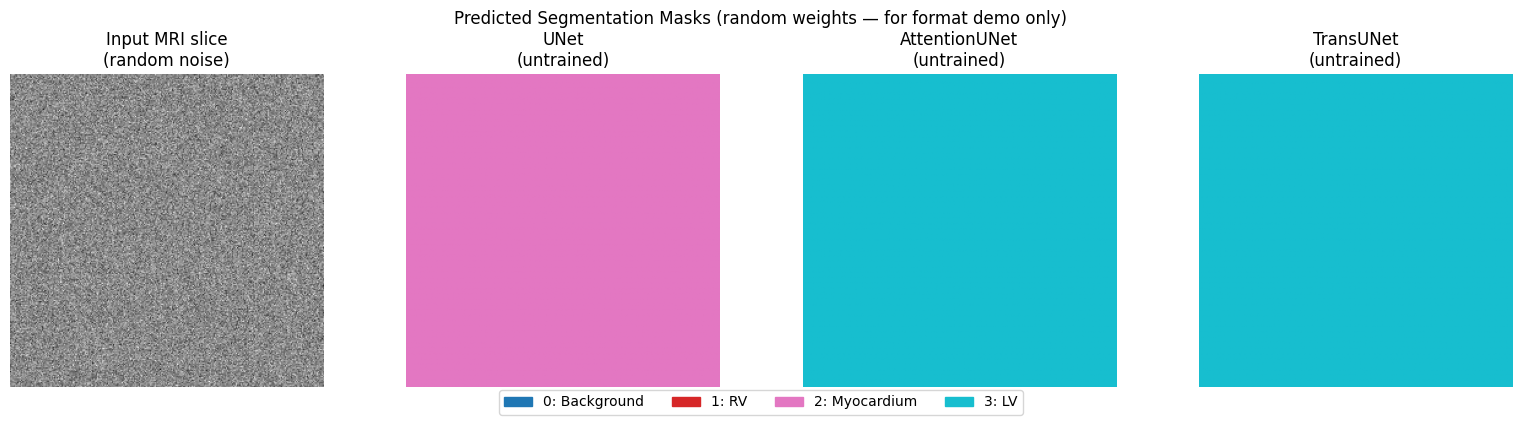

In [9]:
CLASS_LABELS = ["Background", "RV", "Myocardium", "LV"]
CMAP = plt.cm.get_cmap("tab10", 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Show input slice
axes[0].imshow(dummy_input[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title("Input MRI slice\n(random noise)")
axes[0].axis("off")

# Show predicted mask for each model
for ax, (name, model) in zip(axes[1:], models.items()):
    model.eval()
    with torch.no_grad():
        pred = model(dummy_input).argmax(dim=1)[0].cpu().numpy()  # (256, 256)
    im = ax.imshow(pred, cmap=CMAP, vmin=0, vmax=3)
    ax.set_title(f"{name}\n(untrained)")
    ax.axis("off")

# Shared legend
handles = [mpatches.Patch(color=CMAP(i), label=f"{i}: {CLASS_LABELS[i]}") for i in range(4)]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Predicted Segmentation Masks (random weights — for format demo only)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Attention Gate Internals (Attention U-Net)

Hook into the first attention gate to visualise the spatial attention map it produces.

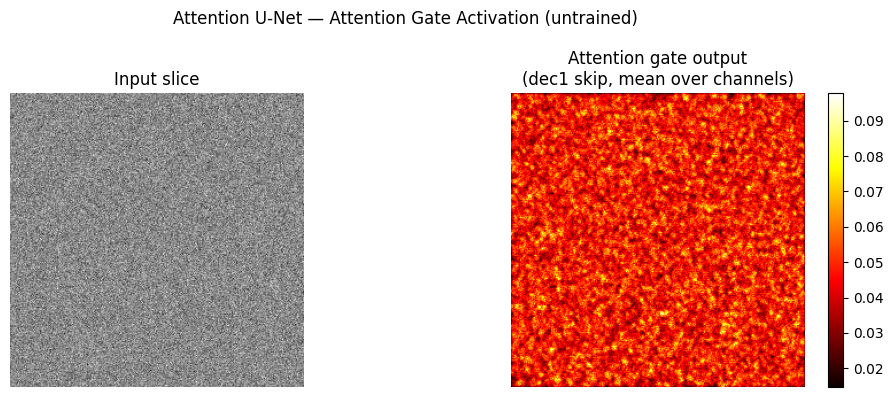

Note: with random weights the attention map is not meaningful.
After training, bright regions should correspond to cardiac structures.


In [10]:
attn_maps = {}

def capture_attn(module, inp, out):
    # out is the attended skip feature (alpha * x)
    # The attention map itself is the mean across channels
    attn_maps["dec1_skip"] = out.detach().cpu()

hook = attn_unet.dec1.attn.register_forward_hook(capture_attn)

attn_unet.eval()
with torch.no_grad():
    _ = attn_unet(dummy_input)

hook.remove()

# The attention-weighted feature map — average across channels gives attention intensity
attn_feat = attn_maps["dec1_skip"][0]          # (64, 256, 256)
attn_mean = attn_feat.mean(dim=0).numpy()       # (256, 256)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(dummy_input[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title("Input slice")
axes[0].axis("off")

im = axes[1].imshow(attn_mean, cmap="hot")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title("Attention gate output\n(dec1 skip, mean over channels)")
axes[1].axis("off")

fig.suptitle("Attention U-Net — Attention Gate Activation (untrained)", fontsize=12)
plt.tight_layout()
plt.show()

print("Note: with random weights the attention map is not meaningful.")
print("After training, bright regions should correspond to cardiac structures.")

---
## 10. Transformer Bottleneck Internals (TransUNet)

Check the token sequence shape inside the Transformer bottleneck.

In [11]:
token_shapes = {}

def capture_proj_in(module, inp, out):
    token_shapes["after_proj_in"] = tuple(out.shape)

def capture_transformer(module, inp, out):
    token_shapes["after_transformer"] = tuple(out.shape)

def capture_proj_out(module, inp, out):
    token_shapes["after_proj_out"] = tuple(out.shape)

h1 = transunet.transformer.proj_in.register_forward_hook(capture_proj_in)
h2 = transunet.transformer.transformer.register_forward_hook(capture_transformer)
h3 = transunet.transformer.proj_out.register_forward_hook(capture_proj_out)

transunet.eval()
with torch.no_grad():
    _ = transunet(dummy_input)

for h in [h1, h2, h3]:
    h.remove()

B, n_tok, d = token_shapes["after_proj_in"]
print("TransUNet Transformer Bottleneck — actual tensor shapes:")
print(f"  CNN feature map in    : (B={B}, C=256, H=16, W=16)   ← pooled enc4 output")
print(f"  Flattened + projected : {token_shapes['after_proj_in']}  ← (B, H*W={n_tok}=16×16, d_model={d})")
print(f"  After Transformer     : {token_shapes['after_transformer']}  ← global context injected")
print(f"  Projected back        : {token_shapes['after_proj_out']}  ← (B, {n_tok}, C=256)")
print(f"  Reshaped to 2D        : (B={B}, C=256, H=16, W=16)   → decoded back up to 256×256")

TransUNet Transformer Bottleneck — actual tensor shapes:
  CNN feature map in    : (B=2, C=256, H=16, W=16)   ← pooled enc4 output
  Flattened + projected : (2, 256, 512)  ← (B, H*W=256=16×16, d_model=512)
  After Transformer     : (2, 256, 512)  ← global context injected
  Projected back        : (2, 256, 256)  ← (B, 256, C=256)
  Reshaped to 2D        : (B=2, C=256, H=16, W=16)   → decoded back up to 256×256


---
## Summary

| Model | Params | Key strength | Main cost |
|---|---|---|---|
| **U-Net** | ~31M | Simple, fast, strong baseline | No long-range context |
| **Attention U-Net** | ~32M | Focuses on relevant structures via gating | Slightly more memory |
| **TransUNet** | ~24M | Global context via Transformer at bottleneck | Slower training (attention is O(n²) in tokens) |

### How to load a trained model

```python
model = UNet(in_channels=1, num_classes=4)
model.load_state_dict(torch.load("checkpoints/unet_best.pth"))
model.eval()
```

### Class label mapping

| Index | Structure |
|---|---|
| 0 | Background |
| 1 | Right Ventricle (RV) |
| 2 | Myocardium |
| 3 | Left Ventricle (LV) |